# CatBoost - Group 6

## Install Libraries

In [ ]:
%pip install catboost

## CatBoost in Regression

We will use the **California Housing Dataset** from `scikit-learn`.

In [2]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

In [3]:
# 1. Load the California Housing Dataset
housing = fetch_california_housing(as_frame=True)
data = housing.frame

# Display dataset info
print("California Housing Dataset Loaded:")
print(f"Samples: {len(data)}, Features: {len(data.columns) - 1}")
print(data.head())

California Housing Dataset Loaded:
Samples: 20640, Features: 8
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [4]:
# 2. Separate features (X) and target (y)
target = "MedHouseVal"
X = data.drop(columns=[target])
y = data[target]

In [ ]:
# 3. Identify categorical features (none in the California Housing dataset)
cat_features = []
# No categorical columns to cast to string, so we bypass that step.

In [6]:
# 4. Train-Test Split using Scikit-Learn (regression task, so we omit 'stratify')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# 5. Initialize CatBoostRegressor (for predicting continuous house values)
model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    random_seed=42,
    verbose=100
)

In [32]:
# 6. Fit the model on training data
model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),  # Optional validation set for early stopping
    early_stopping_rounds=30,  # Stop training if validation score doesn't improve for 30 rounds
)

0:	learn: 1.1244518	test: 1.1141317	best: 1.1141317 (0)	total: 5.83ms	remaining: 17.5s
100:	learn: 0.5369823	test: 0.5577451	best: 0.5577451 (100)	total: 456ms	remaining: 13.1s
200:	learn: 0.4900335	test: 0.5181736	best: 0.5181736 (200)	total: 918ms	remaining: 12.8s
300:	learn: 0.4556483	test: 0.4928652	best: 0.4928652 (300)	total: 1.36s	remaining: 12.2s
400:	learn: 0.4337255	test: 0.4799680	best: 0.4799680 (400)	total: 1.81s	remaining: 11.7s
500:	learn: 0.4161438	test: 0.4714293	best: 0.4714293 (500)	total: 2.25s	remaining: 11.2s
600:	learn: 0.4028231	test: 0.4657025	best: 0.4657025 (600)	total: 2.67s	remaining: 10.7s
700:	learn: 0.3908293	test: 0.4609873	best: 0.4609873 (700)	total: 3.14s	remaining: 10.3s
800:	learn: 0.3798471	test: 0.4568179	best: 0.4568179 (800)	total: 3.58s	remaining: 9.81s
900:	learn: 0.3706700	test: 0.4542457	best: 0.4542457 (900)	total: 4.02s	remaining: 9.38s
1000:	learn: 0.3622172	test: 0.4520175	best: 0.4520080 (999)	total: 4.46s	remaining: 8.9s
1100:	learn: 

CatBoostRegressor(cat_features=[], depth=6, iterations=3000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [33]:
# 7. Make predictions and evaluate using regression metrics
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- Model Evaluation ---
Mean Squared Error (MSE): 0.1899
R-squared (R2) Score: 0.8551


### CatBoost Feature Ranking

Calculate and visualize feature importances directly from a trained model using the `get_feature_importance()` method.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
# type: ignore
# 1. Calculate default feature importance scores (PredictionValuesChange)
feature_importances = model.get_feature_importance()
feature_names = X.columns

In [35]:
# 2. Create a pandas DataFrame for neat display
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importances ---")
print(importance_df)

--- Feature Importances ---
      Feature  Importance
0      MedInc   31.030843
6    Latitude   21.352099
7   Longitude   19.018005
5    AveOccup   14.149368
1    HouseAge    5.655723
2    AveRooms    4.149063
3   AveBedrms    2.350048
4  Population    2.294851


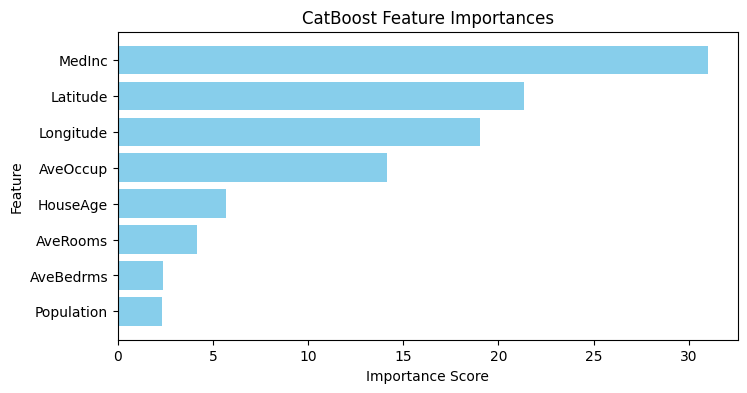

In [36]:
# 3. Plot the feature importances
plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('CatBoost Feature Importances')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

### SHAP Values

**SHAP** stands for **SHapley Additive exPlanations**. It is a widely used framework in machine learning for model interpretability, designed to explain individual predictions by measuring how much each feature contributed to a specific output.

While standard feature importance tells you which features are generally important across an entire dataset, **SHAP values explain** **why** **a specific prediction was made for a single instance**.

### Interpreting SHAP Values

* **Positive SHAP Value**: The feature value pushed the prediction **higher** than the baseline average.
* **Negative SHAP Value**: The feature value pulled the prediction **lower** than the baseline average.
* **Magnitude**: The absolute size of the value indicates how strongly that feature influenced the decision for that specific row.

### Calculating SHAP Values in CatBoost

CatBoost provides built-in support for generating SHAP values, which can be combined with the external `shap` library for visualization

In [37]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Returns Explanation object of shape (samples, features)
print(shap_values.shape)

(4128, 8)


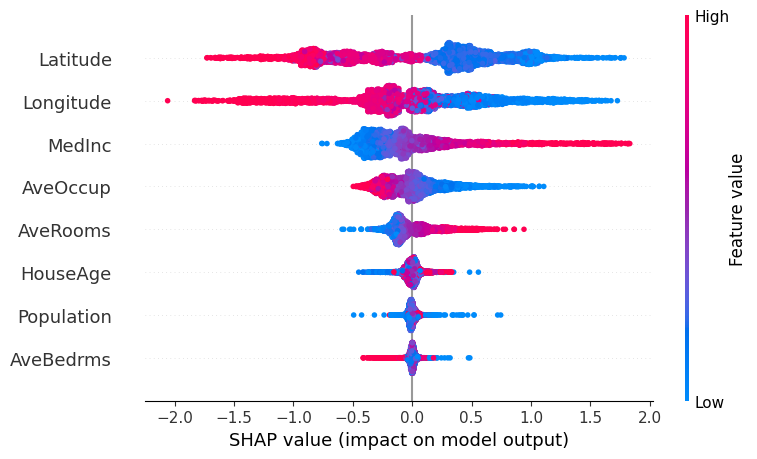

In [38]:
shap.summary_plot(shap_values, X_test)

## CatBoost in Classification

We will use the **Iris Dataset** from `scikit-learn`.

In [16]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [17]:
# 1. Load the Iris dataset
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

In [18]:
# 2. Split into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

In [19]:
# 3. Initialize CatBoostClassifier
clf_model = CatBoostClassifier(
    iterations=150,
    learning_rate=0.05,
    depth=4,
    random_seed=42,
    verbose=50
)

In [20]:
# 4. Fit the classifier
clf_model.fit(
    X_train_iris,
    y_train_iris,
    eval_set=(X_test_iris, y_test_iris),
    early_stopping_rounds=15
)

0:	learn: 1.0396906	test: 1.0408785	best: 1.0408785 (0)	total: 3.06ms	remaining: 456ms
50:	learn: 0.1952153	test: 0.2505788	best: 0.2505788 (50)	total: 47.2ms	remaining: 91.6ms
100:	learn: 0.0951803	test: 0.1794639	best: 0.1794639 (100)	total: 86.3ms	remaining: 41.9ms
149:	learn: 0.0589573	test: 0.1671455	best: 0.1671202 (146)	total: 118ms	remaining: 0us

bestTest = 0.1671202424
bestIteration = 146

Shrink model to first 147 iterations.


CatBoostClassifier(depth=4, iterations=150, learning_rate=0.05, random_seed=42, verbose=50)

In [21]:
# 5. Predict and evaluate
y_pred_iris = clf_model.predict(X_test_iris)
accuracy = accuracy_score(y_test_iris, y_pred_iris)

print("\n--- Iris Classification Model Evaluation ---")
print(f"Accuracy Score: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_iris, y_pred_iris, target_names=iris.target_names))


--- Iris Classification Model Evaluation ---
Accuracy Score: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### CatBoost Feature Ranking

Calculate and visualize feature importances directly from a trained model using the `get_feature_importance()` method.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# type: ignore
# 1. Calculate default feature importance scores for Iris classification
feature_importances = clf_model.get_feature_importance()
feature_names = X_iris.columns

In [24]:
# 2. Create a pandas DataFrame for neat display
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("--- Iris Feature Importances ---")
print(importance_df)

--- Iris Feature Importances ---
             Feature  Importance
3   petal width (cm)   48.755999
2  petal length (cm)   37.752506
1   sepal width (cm)    7.278262
0  sepal length (cm)    6.213233


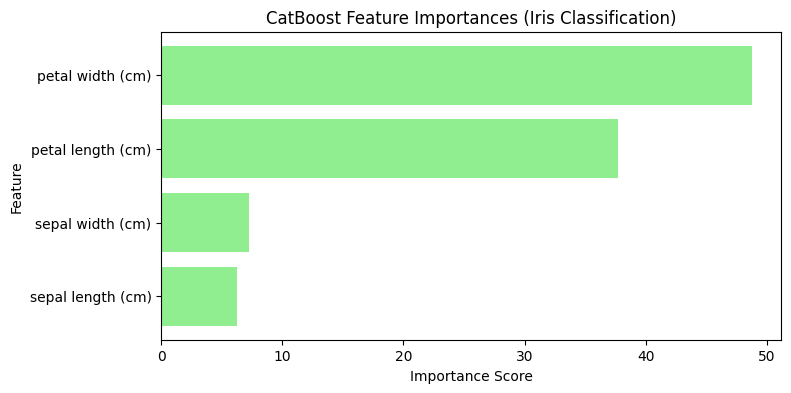

In [25]:
# 3. Plot the feature importances for Iris dataset
plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='lightgreen')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('CatBoost Feature Importances (Iris Classification)')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

### SHAP Values with `shap.TreeExplainer()`

In [26]:
import shap

explainer = shap.TreeExplainer(clf_model)
shap_exp = explainer(X_test_iris)

# Shape: (samples, features, classes)
print(shap_exp.shape)

(30, 4, 3)


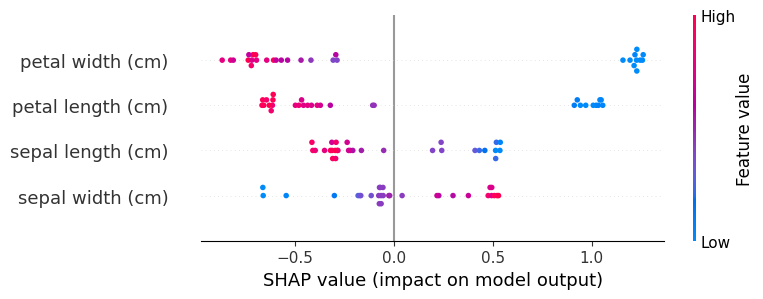

In [27]:
# Single-class summary plot
shap.summary_plot(shap_exp[:, :, 0], X_test_iris)

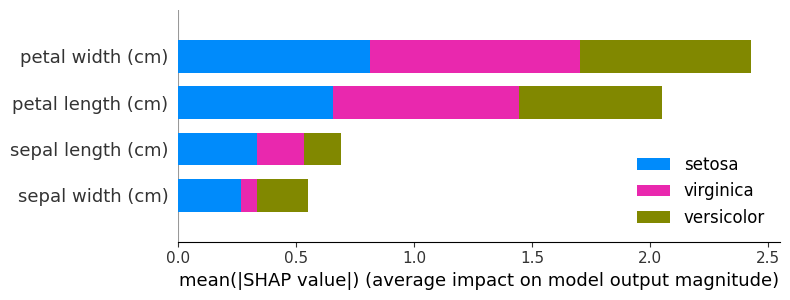

In [28]:
# Multi-class bar summary plot for all classes at once
shap.summary_plot(
    [shap_exp.values[:, :, i] for i in range(3)],
    X_test_iris,
    class_names=iris.target_names,
)